In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
min_k_clusters = int(config["min_k_clusters"])
max_k_clusters = int(config["max_k_clusters"])
k_final = int(config["k_final"])

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

print(f"Rango de clusters: {min_k_clusters} a {max_k_clusters}")
print(f"k_final: {k_final}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline
Rango de clusters: 2 a 8
k_final: 4


# CARGA DE DATOS

In [2]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df_oleaje = pd.read_csv(os.path.join(base_path, "df_wave.csv"))
df_features = pd.read_csv(os.path.join(base_path, "df_features.csv"))

df = pd.merge(
    df_oleaje,
    df_features,
    on="window_id",
    how="inner"
)

df_oleaje.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vx,mean_vy,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vel_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-1.714890,3.480262,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-1.702691,4.693565,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-1.457192,4.596101,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.720594,4.239672,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.909696,3.509688,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


# IMPLEMENTACIÓN K-MEANS

## Algoritmo K-Means

K-Means es un algoritmo de clustering no supervisado que particiona las observaciones en $k$ grupos, minimizando la suma de distancias euclídeas al cuadrado entre cada punto y el centroide de su cluster asignado.

**Pasos del algoritmo:**
1. Se inicializan $k$ centroides aleatoriamente (se usa `n_init=20` para reducir la sensibilidad a la inicialización).
2. Cada observación se asigna al centroide más cercano.
3. Los centroides se recalculan como la media de los puntos asignados.
4. Se repiten los pasos 2–3 hasta convergencia.

## Preprocesamiento de variables

Antes de aplicar K-Means, las variables de entrada se preprocesan:
- **Imputación**: los valores faltantes se sustituyen por la mediana de cada variable (`SimpleImputer(strategy="median")`), evitando la influencia de outliers.
- **Estandarización**: se aplica `StandardScaler` para centrar y escalar cada variable a media 0 y desviación típica 1, garantizando que todas contribuyan equitativamente a la distancia euclídea.

## Métricas de evaluación del clustering

- **Método del codo (Elbow)**: se representa la inercia (suma de distancias intra-cluster al cuadrado) frente a $k$. El "codo" indica el punto a partir del cual añadir más clusters no reduce significativamente la inercia.
- **Coeficiente de Silhouette**: mide la cohesión y separación de los clusters. Varía entre −1 y 1; valores altos indican clusters bien definidos y separados.

## Criterio de selección

La selección de la combinación óptima (fuente de oleaje × número de clusters) se basa en tres criterios simultáneos:
1. **Significancia estadística**: el contraste sobre `flux_O2` entre grupos debe ser significativo ($p < 0{,}05$).
2. **Coherencia física**: la diferencia de mediana del flujo ($\Delta$ mediana) debe ser negativa, reflejando que más oleaje se asocia a mayor consumo de oxígeno.
3. **Calidad del clustering**: entre las combinaciones que cumplen los dos criterios anteriores, se elige la de mayor coeficiente de silhouette.

## Reordenación de clusters

Dado que K-Means asigna etiquetas de cluster de forma arbitraria, tras cada ajuste se reordenan los clusters por la media ascendente de la variable de oleaje. Así, el cluster 0 siempre corresponde a "poco oleaje" y el cluster más alto a "mucho oleaje", facilitando la interpretación física de los resultados.

# VARIABLES

In [37]:
# Variables comunes de presión
pres_features = [
    "pres__mean",
    "pres__standard_deviation",
    "pres__median",
]

# Definición de escenarios
escenarios = {
    "Wiberg": {
        "features": ["Oleaje", "Mod_orbital", "STD_orbital"] + pres_features,
        "col_oleaje": "Oleaje",
    },
    "SIMAR": {
        "features": ["Oleaje_SIMAR"] + pres_features,
        "col_oleaje": "Oleaje_SIMAR",
    },
}

for nombre, esc in escenarios.items():
    print(f"{nombre}: {esc['features']}")

Wiberg: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'pres__mean', 'pres__standard_deviation', 'pres__median']
SIMAR: ['Oleaje_SIMAR', 'pres__mean', 'pres__standard_deviation', 'pres__median']


In [38]:
# Preprocesado para cada escenario
X_scaled_dict = {}

for nombre, esc in escenarios.items():
    X = df[esc["features"]].copy()
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_scaled_dict[nombre] = scaler.fit_transform(imputer.fit_transform(X))
    print(f"{nombre}: {X_scaled_dict[nombre].shape}")

Wiberg: (568, 6)
SIMAR: (568, 4)


# SELECCIÓN DE FUENTE DE OLEAJE Y NÚMERO DE CLUSTERS

Antes de aplicar la clasificación definitiva, se evalúan todas las combinaciones escenario × k para seleccionar la fuente de oleaje y el número de clusters óptimos.

Criterios de evaluación:
- **Silhouette**: calidad interna del clustering
- **Test sobre flux_O2**: Mann-Whitney U (k=2) o Kruskal-Wallis (k>2)

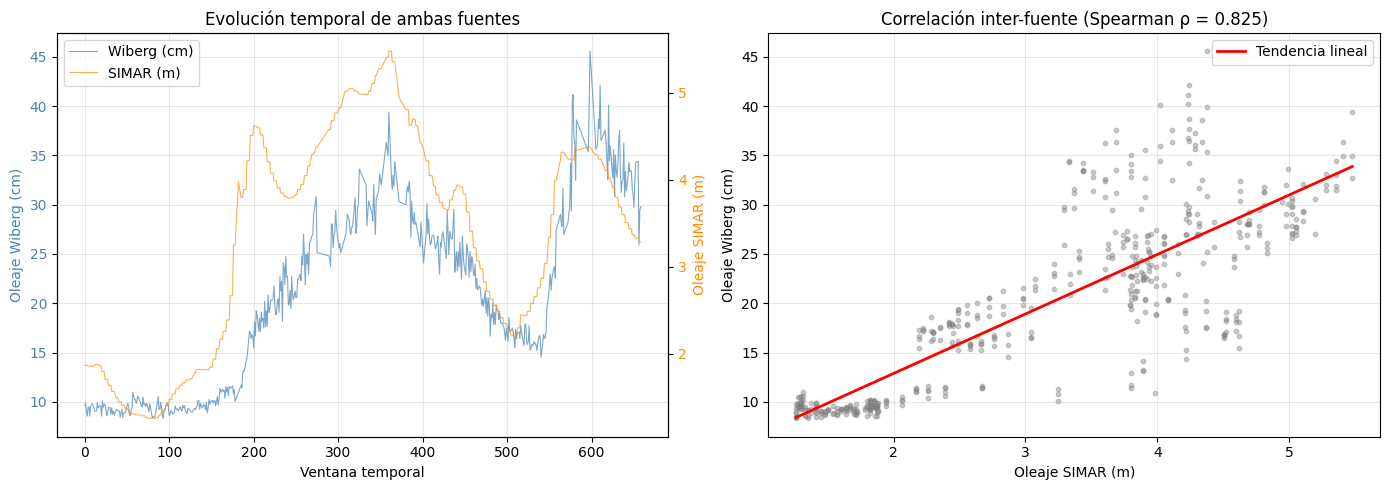

In [39]:
# ============================================================
# FIGURA: Evolución temporal y correlación entre fuentes
# ============================================================
from scipy.stats import spearmanr

# Correlación de Spearman entre ambas fuentes de oleaje
aux_corr = df[["Oleaje", "Oleaje_SIMAR"]].dropna()
rho_inter, _ = spearmanr(aux_corr["Oleaje"], aux_corr["Oleaje_SIMAR"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: serie temporal de ambas fuentes (doble eje Y por las unidades)
ax1 = axes[0]
ax1_twin = ax1.twinx()

aux_ts = df[["window_id", "Oleaje", "Oleaje_SIMAR"]].dropna()
ax1.plot(aux_ts["window_id"], aux_ts["Oleaje"], color="steelblue", alpha=0.7, linewidth=0.8, label="Wiberg (cm)")
ax1_twin.plot(aux_ts["window_id"], aux_ts["Oleaje_SIMAR"], color="darkorange", alpha=0.7, linewidth=0.8, label="SIMAR (m)")

ax1.set_xlabel("Ventana temporal")
ax1.set_ylabel("Oleaje Wiberg (cm)", color="steelblue")
ax1_twin.set_ylabel("Oleaje SIMAR (m)", color="darkorange")
ax1.set_title("Evolución temporal de ambas fuentes")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1_twin.tick_params(axis="y", labelcolor="darkorange")

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(True, alpha=0.3)

# Panel derecho: scatter con línea de tendencia
ax2 = axes[1]
aux_sc = df[["Oleaje", "Oleaje_SIMAR"]].dropna()
ax2.scatter(aux_sc["Oleaje_SIMAR"], aux_sc["Oleaje"], s=10, alpha=0.4, color="gray")

# Línea de tendencia (regresión lineal para referencia visual)
z = np.polyfit(aux_sc["Oleaje_SIMAR"], aux_sc["Oleaje"], 1)
x_line = np.linspace(aux_sc["Oleaje_SIMAR"].min(), aux_sc["Oleaje_SIMAR"].max(), 100)
ax2.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2, label="Tendencia lineal")

ax2.set_xlabel("Oleaje SIMAR (m)")
ax2.set_ylabel("Oleaje Wiberg (cm)")
ax2.set_title(f"Correlación inter-fuente (Spearman ρ = {rho_inter:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Gráficas del estudio comparativo

C:\Users\noeli\AppData\Local\Temp\ipykernel_11488\1759323492.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\noeli\AppData\Local\Temp\ipykernel_11488\1759323492.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


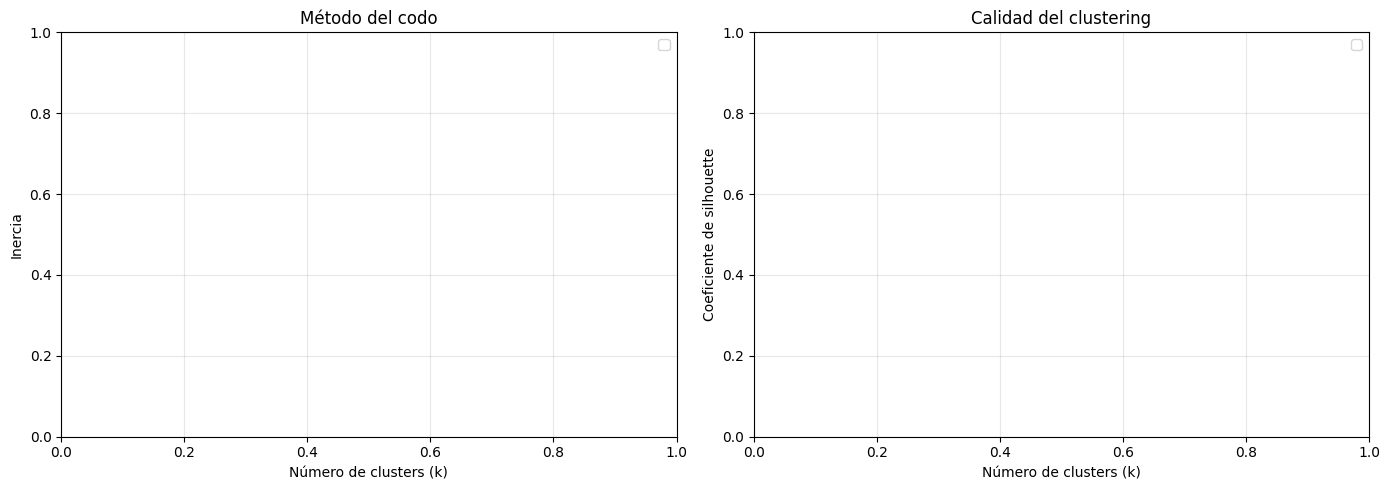

In [40]:
# ============================================================
# FIGURA: Método del codo + Silhouette
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, df_k in resultados_k.items():
    axes[0].plot(df_k["k"], df_k["inertia"], marker="o", label=nombre)
    axes[1].plot(df_k["k"], df_k["silhouette"], marker="o", label=nombre)

axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silhouette")
axes[1].set_title("Calidad del clustering")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# CLASIFICACIÓN DEFINITIVA

Se aplica K-Means con la combinación seleccionada (escenario Wiberg, k según config.xlsx).
Se clasifica también con SIMAR para poder hacer la comparación entre clasificaciones.

In [41]:
# Aplicar K-Means con k_final a cada escenario
if k_final == 2:
    nombres_clase = {0: "poco_oleaje", 1: "mucho_oleaje"}
else:
    nombres_clase = {i: f"clase_{i}" for i in range(k_final)}

for nombre, esc in escenarios.items():
    X_scaled = X_scaled_dict[nombre]
    col_oleaje = esc["col_oleaje"]

    kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
    labels_raw = kmeans.fit_predict(X_scaled)

    # Reordenar clusters por oleaje medio ascendente
    df_tmp = df[[col_oleaje]].copy()
    df_tmp["label"] = labels_raw
    orden = df_tmp.groupby("label")[col_oleaje].mean().sort_values().index.tolist()
    mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
    labels_sorted = np.array([mapa[l] for l in labels_raw])

    # Guardar en columnas separadas
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    df[col_clase] = labels_sorted
    df[col_nombre_clase] = df[col_clase].map(nombres_clase)

    sil = silhouette_score(X_scaled, labels_sorted)
    print(f"\n=== {nombre} (k={k_final}) ===")
    print(f"  Silhouette: {sil:.4f}")
    print(f"  Distribución: {dict(pd.Series(labels_sorted).value_counts().sort_index())}")


=== Wiberg (k=4) ===
  Silhouette: 0.3867
  Distribución: {0: np.int64(118), 1: np.int64(157), 2: np.int64(139), 3: np.int64(154)}

=== SIMAR (k=4) ===
  Silhouette: 0.4228
  Distribución: {0: np.int64(108), 1: np.int64(137), 2: np.int64(157), 3: np.int64(166)}


In [42]:
# Resumen por clase para cada escenario
for nombre, esc in escenarios.items():
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    print(f"\n{'='*60}")
    print(f"RESUMEN — {nombre}")
    print(f"{'='*60}")
    display(
        df.groupby([col_clase, col_nombre_clase])[esc["features"]]
        .agg(["count", "mean", "std", "median"])
        .round(4)
    )


RESUMEN — Wiberg


Oleaje                   \
                                                count     mean     std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                       116  11.6664  3.3476   
1                   clase_1                       151  13.6720  4.6220   
2                   clase_2                       120  24.4553  3.8546   
3                   clase_3                       124  31.1267  4.5902   

                                                       Mod_orbital          \
                                                median       count    mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   clase_0                      9.910         118  0.0186   
1                   clase_1                     11.716         157  0.0231   
2                   clase_2                     24.412         139  0.0457   
3                   clase_3                     30.830         154  0.0579   

                                                               STD_orbital  \
                                                   std  median       count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   clase_0                     0.0070  0.0151         118   
1                   clase_1                     0.0096  0.0210         157   
2                   clase_2                     0.0087  0.0451         139   
3                   clase_3                     0.0094  0.0573         154   

                                                        ... pres__mean  \
                                                  mean  ...        std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre          ...              
0                   clase_0                     0.0120  ...    35.3761   
1                   clase_1                     0.0153  ...    38.8089   
2                   clase_2                     0.0299  ...    30.8265   
3                   clase_3                     0.0392  ...    43.2881   

                                                           \
                                                   median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre              
0                   clase_0                     1618.3358   
1                   clase_1                     1475.6241   
2                   clase_2                     1592.0342   
3                   clase_3                     1502.3152   

                                               pres__standard_deviation  \
                                                                  count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                            
0                   clase_0                                         118   
1                   clase_1                                         157   
2                   clase_2                                         139   
3                   clase_3                                         154   

                                                                        \
                                                  mean     std  median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                     4.1725  0.9309  4.3204   
1                   clase_1                     4.5078  1.0799  4.6561   
2                   clase_2                     6.7582  1.0044  6.6464   
3                   clase_3                     8.2611  1.1571  8.0998   

                                               pres__median             \
                                                      count       mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                             118  1614.0678   
1                   clase_1                             157  1470.0650   
2                   clase_2                             139  1589.6207  


RESUMEN — SIMAR


Oleaje_SIMAR                  \
                                                    count    mean     std   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                            108  1.8488  0.3810   
1                  clase_1                            137  2.1683  0.7491   
2                  clase_2                            157  4.2323  0.4968   
3                  clase_3                            166  4.2405  0.6373   

                                                    pres__mean             \
                                             median      count       mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                     1.86        108  1612.1057   
1                  clase_1                     1.85        137  1472.6922   
2                  clase_2                     4.24        157  1489.6284   
3                  clase_3                     4.22        166  1594.5492   

                                                                  \
                                                  std     median   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                       
0                  clase_0                    36.1250  1609.9184   
1                  clase_1                    40.6240  1479.3028   
2                  clase_2                    31.3253  1490.0354   
3                  clase_3                    27.2227  1594.2891   

                                             pres__standard_deviation          \
                                                                count    mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                    
0                  clase_0                                        108  4.1107   
1                  clase_1                                        137  4.2990   
2                  clase_2                                        157  7.6388   
3                  clase_3                                        166  7.1052   

                                                             pres__median  \
                                                 std  median        count   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                    0.9428  4.2320          108   
1                  clase_1                    0.9875  4.3827          137   
2                  clase_2                    1.3071  7.6539          157   
3                  clase_3                    1.4311  6.8976          166   

                                                                           
                                                   mean      std   median  
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                               
0                  clase_0                    1612.1407  36.0693  1610.00  
1                  clase_1                    1472.6593  40.6386  1479.35  
2                  clase_2                    1489.6570  31.3446  1490.15  
3                  clase_3                    1594.5736  27.2204  1594.30

# COMPARACIÓN ENTRE CLASIFICACIONES Y COMPROBACIONES

In [43]:
# ============================================================
# CONCORDANCIA: tabla de contingencia entre clasificaciones
# ============================================================

if "oleaje_clase_Wiberg" in df.columns and "oleaje_clase_SIMAR" in df.columns:
    tabla_contingencia = pd.crosstab(
        df["oleaje_clase_Wiberg_nombre"],
        df["oleaje_clase_SIMAR_nombre"],
        rownames=["Wiberg"],
        colnames=["SIMAR"],
    )
    display(tabla_contingencia)

    concordancia = (df["oleaje_clase_Wiberg"] == df["oleaje_clase_SIMAR"]).mean() * 100
    print(f"\nConcordancia: {concordancia:.1f}% de ventanas clasificadas igual")
else:
    print("Faltan columnas de clasificación.")

SIMAR,clase_0,clase_1,clase_2,clase_3
Wiberg,,,,
clase_0,104,1,0,13
clase_1,0,132,25,0
clase_2,4,4,6,125
clase_3,0,0,126,28



Concordancia: 47.5% de ventanas clasificadas igual


# CREACIÓN DE FICHEROS CON LOS DATOS CLASIFICADOS

In [44]:
# Columnas de clasificación generadas
cols_clase = [c for c in df.columns if c.startswith("oleaje_clase_")]
print("Columnas de clasificación guardadas:")
print(cols_clase)

output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_classified.csv")
df.to_csv(output_path, index=False)
print(f"\nDatos guardados en: {output_path}")

Columnas de clasificación guardadas:
['oleaje_clase_Wiberg', 'oleaje_clase_Wiberg_nombre', 'oleaje_clase_SIMAR', 'oleaje_clase_SIMAR_nombre']

Datos guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\PROCESSED\df_classified.csv
